# Visualizing spectrograms from saved datasets

In [1]:
print("Hello world")

Hello world


In [4]:
"""Load saved SpectrogramDataset checkpoints and plot random mel spectrograms."""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from audio_sanity_checks.config import PROCESSED_DATA_DIR
from audio_sanity_checks.spectrograms import ESC50SpectrogramDataset, SpeechCommandsSpectrogramDataset


def load_spectrogram_dataset(pt_path: Path):
    """Load a dataset saved with ``torch.save`` from ``spectrograms.py``."""
    return torch.load(pt_path, weights_only=False)


def plot_mel_batch(
    dataset,
    indices,
    *,
    log_scale: bool = True,
    figsize_per_col: float = 3.5,
    row_height: float = 3.0,
):
    """Plot mel spectrograms for the given sample indices (each row: spec + label title)."""
    n = len(indices)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_col * n, row_height))
    if n == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        spec, label = dataset[idx]
        mel = spec.squeeze(0).detach().cpu().numpy()
        if log_scale:
            mel = 10.0 * np.log10(np.maximum(mel, 1e-10))

        ax.imshow(mel, aspect="auto", origin="lower", interpolation="nearest")
        ax.set_title(str(label), fontsize=10)
        ax.set_xlabel("frame")
        ax.set_ylabel("mel bin")

    plt.tight_layout()
    plt.show()


def show_random_from_file(pt_path: Path, n: int = 4, seed: int = 0):
    ds = load_spectrogram_dataset(pt_path)
    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(len(ds), generator=g)[:n]
    plot_mel_batch(ds, perm.tolist())


speech_commands\speech_commands_testing.pt — 11005 samples


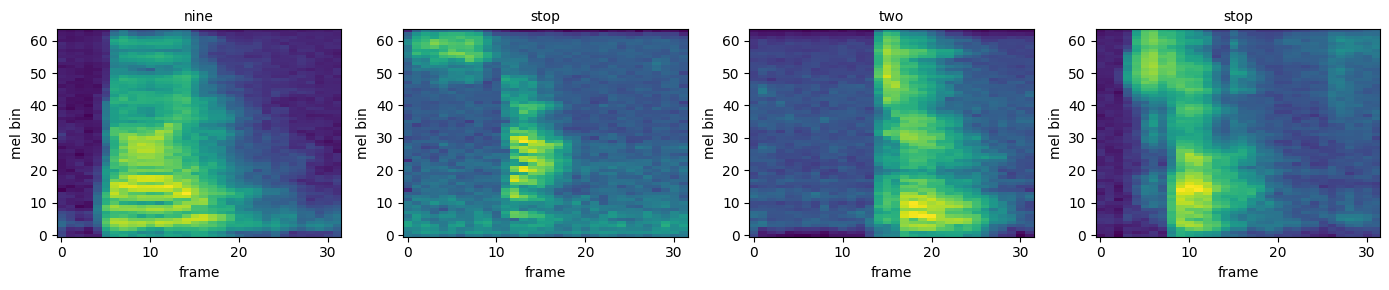

speech_commands\speech_commands_training.pt — 84843 samples


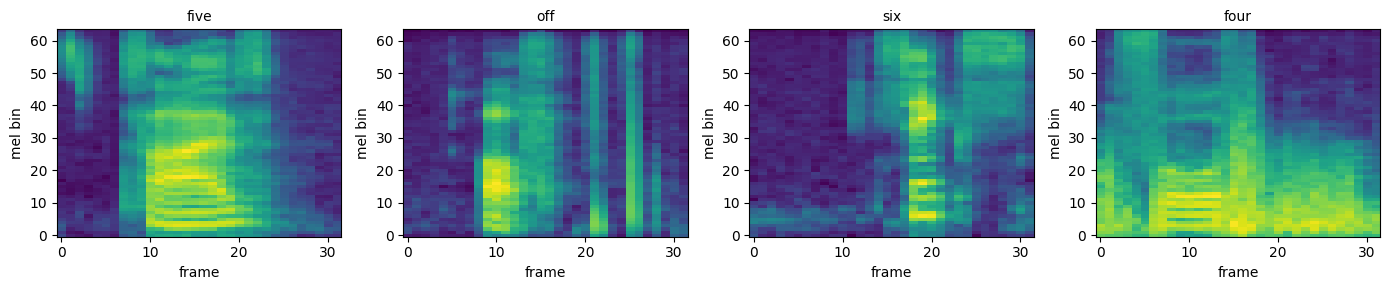

speech_commands\speech_commands_validation.pt — 9981 samples


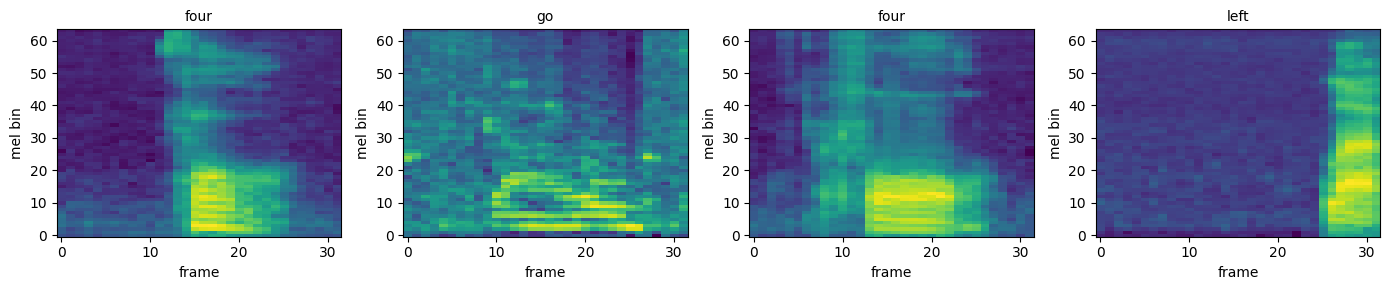

esc50\esc50_testing.pt — 400 samples


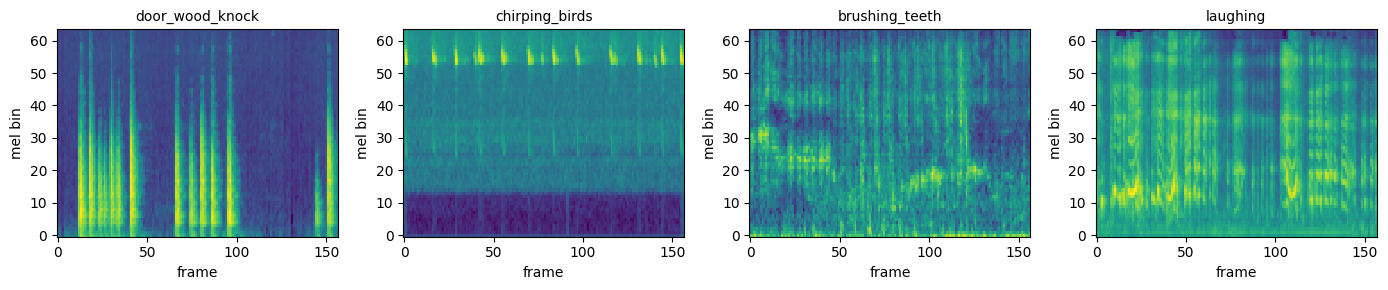

esc50\esc50_training.pt — 1200 samples


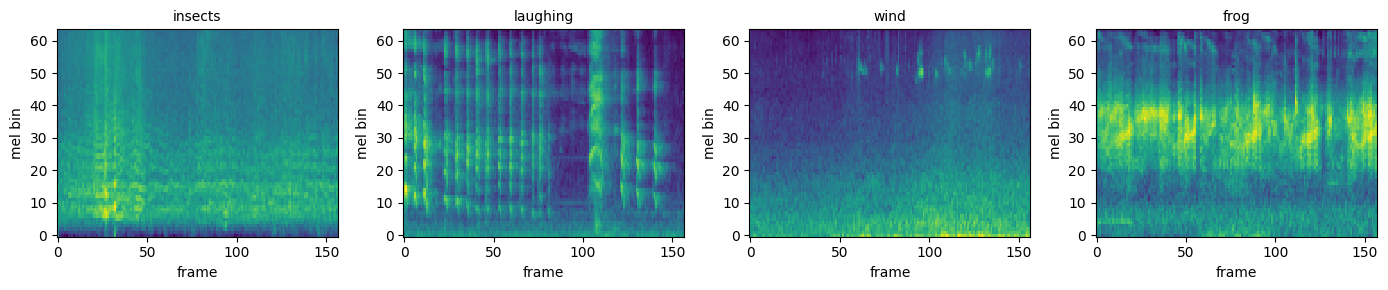

esc50\esc50_validation.pt — 400 samples


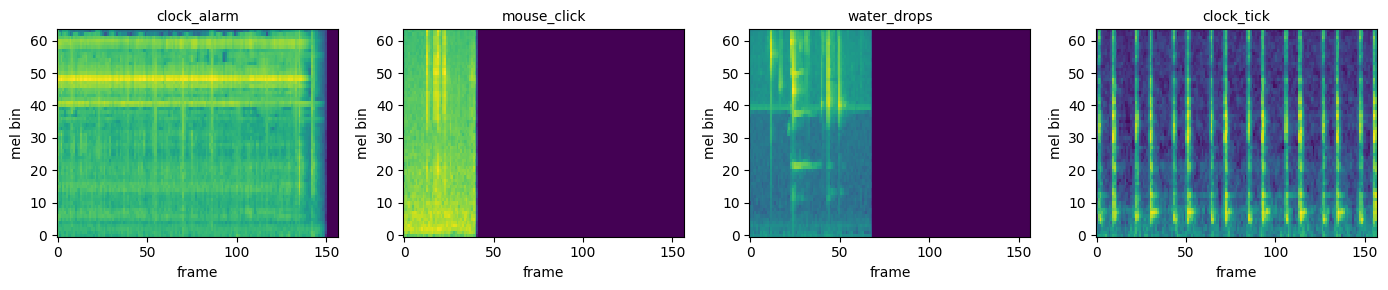

In [5]:


for subdir in ("speech_commands", "esc50"):
    d = PROCESSED_DATA_DIR / subdir
    if not d.is_dir():
        continue
    files = sorted(d.glob("*.pt"))
    if not files:
        print(f"No .pt files in {d}")
        continue
    for pt in files:
        ds = load_spectrogram_dataset(pt)
        print(f"{pt.relative_to(PROCESSED_DATA_DIR)} — {len(ds)} samples")
        g = torch.Generator().manual_seed(42)
        perm = torch.randperm(len(ds), generator=g)[:4]
        plot_mel_batch(ds, perm.tolist())